In [1]:
import pennylane as qml
import kak_tools as kak
import numpy as np
import scipy as sp
from functools import partial
import time
from tqdm.notebook import tqdm
import matplotlib.pyplot as plt

In [2]:
def diag_decomp_two_qubits(u, wires, validate=True):
    """Compute the decomposition of a two-qubit unitary into a diagonal and a remaining decomposition as
    reported in Theorem 14 of the QSD paper (Shende et al. https://arxiv.org/pdf/quant-ph/0406176)."""
    if validate:
        assert u.shape == (4, 4)
        assert np.allclose(u @ u.conj().T, np.eye(4))

    u_mod = u @ _CNOT
    ops = asymmetric_two_qubit_decomp(u_mod, wires, validate=validate)
    rz = ops[0]
    a_op = ops[-3]
    a_dec = qml.ops.op_math.decompositions.one_qubit_decomposition(a_op.data[0], wire=wires[0])
    b_op = ops[-2]
    b_dec = qml.ops.op_math.decompositions.one_qubit_decomposition(b_op.data[0], wire=wires[1])
    c_op = ops[2]
    c_rz0, c_ry, c_rz1 = qml.ops.op_math.decompositions.one_qubit_decomposition(c_op.data[0], wire=wires[0])
    d_op = ops[3]
    d_rz0, d_ry, d_rz1 = qml.ops.op_math.decompositions.one_qubit_decomposition(d_op.data[0], wire=wires[1])
    rest_ops = ops[4:-3] + a_dec + b_dec
    gphase = ops[-1]
    diag_ops = [qml.IsingZZ(rz.data[0], wires=wires), c_rz0, d_rz0, gphase]
    diagonal = np.diag(qml.matrix(qml.prod(*diag_ops[::-1]), wire_order=wires))
    diag_op = qml.DiagonalQubitUnitary(diagonal, wires=wires)
    rest_ops = [c_ry, c_rz1, d_ry, d_rz1, *rest_ops]

    if validate:
        u_rec = qml.matrix(qml.tape.QuantumScript([diag_op] + rest_ops), wire_order=wires)
        assert np.allclose(u, u_rec)
    return diag_op, rest_ops
        
# matrix functions
_CNOT = qml.CNOT([0, 1]).matrix()
_YY = qml.matrix(qml.Y(0) @ qml.Y(1), wire_order=[0, 1])
_RZ = qml.matrix(partial(qml.RZ, wires=1), wire_order=[0, 1])
@partial(qml.matrix, wire_order=[0, 1])
def _RX_RZ(theta, phi):
    qml.RX(theta, 0)
    qml.RZ(phi, 1)
_E = np.array([[1, 1j, 0, 0], [0, 0, 1j, 1], [0, 0, 1j, -1], [1, -1j, 0, 0]]) / np.sqrt(2)

def asymmetric_two_qubit_decomp(u, wires, validate=True):
    """Compute an alternative 3-CNOT decomposition of a two-qubit unitary
    that is less symmetric in terms of the location of the used single-parameter one-qubit blocks.
    This decomposition is reported in Theorem VI.3 and Fig. 3 of https://arxiv.org/pdf/quant-ph/0308033."""
    if validate:
        assert u.shape == (4, 4)
        assert np.allclose(u @ u.conj().T, np.eye(4))
    u_mod = u @ _CNOT
    gphase = np.angle(np.linalg.det(u_mod))/4
    u_mod = np.exp(-1j * gphase) * u_mod

    with qml.queuing.QueuingManager.stop_recording():
        Psi, Theta, Phi = _prop_V2(u_mod, validate=validate)
        U = u_mod @ _CNOT @ _RZ(Psi) @ _CNOT
        V = _CNOT @ _RX_RZ(Theta, Phi) @ _CNOT
        a, b, c, d = _prop_IV3(U, V, validate=validate)
        if validate:
            assert np.allclose(np.kron(a, b) @ V @ np.kron(c, d), U)
            assert np.allclose(u_mod, np.kron(a, b) @ V @ np.kron(c, d) @ _CNOT @ _RZ(-Psi) @ _CNOT)
    
    ops = [
        qml.RZ(-Psi, wires[1]),
        qml.CNOT(wires),
        qml.QubitUnitary(c, wires[0]),
        qml.QubitUnitary(d, wires[1]),
        qml.CNOT(wires),
        qml.RX(Theta, wires[0]),
        qml.RZ(Phi, wires[1]),
        qml.CNOT(wires),
        qml.QubitUnitary(a, wires[0]),
        qml.QubitUnitary(b, wires[1]),
        qml.GlobalPhase(-gphase),
    ]
    if validate:
        u_rec = qml.matrix(qml.tape.QuantumScript(ops), wire_order=wires)
        assert np.allclose(u, u_rec)
    return ops
        

def _gamma(u):
    """Compute complex relative structure for AI decomposition in magic basis rep."""
    return u @ _YY @ u.T @ _YY

def _complex_sort(x):
    """Sort (and modify!) a complex-valued array by sorting Re(x) + 10⁵ Im(x)."""
    return np.sort(x.real + x.imag * 1e5)

def _prop_V2(u, validate=True):
    """Implement Proposition V.2 from https://arxiv.org/pdf/quant-ph/0308033, namely
    find three angles Psi, Theta and Phi such that the eigenvalues of

    γ(u CNOT(0,1) RZ(Psi, 1) CNOT(0,1)) 

    and

    γ(CNOT(0,1) RX(Theta, 0) RZ(Phi, 1) CNOT(0,1))

    are equal.
    """
    t = np.diag(_gamma(u.T).T)
    Psi = np.arctan(np.sum(t).imag / (t[0]+t[3]-t[1]-t[2]).real)
    m = _gamma(u @ _CNOT @ _RZ(Psi) @ _CNOT)
    evals = np.linalg.eigvals(m)
    eval_angles = np.sort(np.angle(evals))
    r, s = eval_angles[2:]
    Theta = (r+s)/2
    Phi = (r-s) / 2

    if validate:
        assert np.allclose(np.linalg.det(m), 1.)
        assert np.allclose(m @ m.conj().T, np.eye(4))
        assert np.isclose(np.trace(m).imag, 0.)
        assert np.isclose(eval_angles[0], -eval_angles[3]) and np.isclose(eval_angles[1], -eval_angles[2])
        # Test
        left = _complex_sort(np.linalg.eigvals(m))
        right = _complex_sort(np.linalg.eigvals(_gamma(_CNOT @ _RX_RZ(Theta, Phi) @ _CNOT)))
        assert np.allclose(left, right), f"{left=}\n{right=}"
    
    return Psi, Theta, Phi

def _prop_IV3(u, v, validate=True):
    """Given two matrices that are guaranteed to be equal up to conjugation
    by single-qubit unitaries, find the single-qubit unitaries ``a,b,c,d``
    such that

    ``u = kron(a, b) @ v @ kron(c, d)``.
    """
    # Move u and v to new representation of unitary group. This is necessary
    # because we want to move the AI subgroup SO(4) back to the standard rep of SU(2)xSU(2)
    # later on by undoing this representation change.
    new_u = _E.conj().T @ u @ _E
    new_v = _E.conj().T @ v @ _E
    # Compute relative complex structures for AI decomposition in its standard rep.
    delta_u = new_u @ new_u.T
    delta_v = new_v @ new_v.T

    # Rescaled real and imaginary parts for real-valued diagonalization of u and v
    pi_u = delta_u.real*np.pi**2 + delta_u.imag /np.pi**2 
    pi_v = delta_v.real*np.pi**2 + delta_v.imag /np.pi**2
    # Compute real-valued diagonalization
    eigvals_u, a = np.linalg.eigh(pi_u)
    eigvals_v, b = np.linalg.eigh(pi_v)
    # Fix determinants
    a[:, 0] *= np.linalg.det(a)
    b[:, 0] *= np.linalg.det(b)
    c = new_v.conj().T @ b @ a.T @ new_u
    
    if validate:
        assert np.allclose(pi_u, pi_u.T)
        assert np.allclose(pi_v, pi_v.T)
        assert np.allclose(eigvals_u, eigvals_v)
        assert np.allclose(a.T @ pi_u @ a, np.diag(eigvals_u))
        assert np.allclose(b.T @ pi_v @ b, np.diag(eigvals_v))
        assert np.allclose((a @ b.T).T @ (a @ b.T), np.eye(4))
        assert np.allclose(c.T @ c, np.eye(4))
        
    # Move the subgroup elements a @ b.T and c from the standard rep of SO(4)
    # back to the standard rep of SU(2)xSU(2), and decompose the result into single-qubit ops.
    left_su2_su2 = _E @ a @ b.T @ _E.conj().T
    right_su2_su2 = _E @ c @ _E.conj().T
    a, b = qml.math.decomposition.su2su2_to_tensor_products(left_su2_su2)
    c, d = qml.math.decomposition.su2su2_to_tensor_products(right_su2_su2)
    
    if validate:
        assert np.allclose(np.kron(a, b), left_su2_su2), f"\n{np.kron(a, b)=}\n{left_su2_su2=}"
        assert np.allclose(np.kron(c, d), right_su2_su2)
        assert np.allclose(np.kron(a, b) @ v @ np.kron(c, d), u)
    return a, b, c, d
    

In [3]:
u = sp.stats.unitary_group.rvs(4)
wires = [0, 1]
ops = asymmetric_two_qubit_decomp(u, wires=wires)
diag_op, rest_ops = diag_decomp_two_qubits(u, wires=wires)

In [4]:
def _split_diag(D):
    angles = qml.math.angle(D)   
    n = len(D) // 2
    diff = angles[..., n:] - angles[..., :n]                                                    
    mean = (angles[..., :n] + angles[..., n:]) / 2                                                                                                                                     
    return np.exp(1j * mean), diff 

def _attach_multiplexer_node(ops0, ops1, multiplexer_wire, validate=True):
    if validate:
        assert all(isinstance(op0, type(op1)) for op0, op1 in zip(ops0, ops1, strict=True))
        assert all(op0.wires==op1.wires for op0, op1 in zip(ops0, ops1))
        
    new_ops = []
    for op0, op1 in zip(ops0, ops1):
        if isinstance(op0, (qml.RX, qml.RY, qml.RZ)):
            new_ops.append(qml.SelectPauliRot(
                angles=[op0.data[0], op1.data[0]],
                control_wires=[multiplexer_wire],
                target_wire=op0.wires[0],
                rot_axis=op0.name[-1],
            ))
        elif isinstance(op0, (qml.CNOT, qml.CZ)):
            new_ops.append(op0)
            if qml.queuing.QueuingManager.recording():
                qml.apply(op0)
        elif isinstance(op0, qml.SelectPauliRot):
            new_ops.append(qml.SelectPauliRot(
                angles=np.concatenate([op0.data[0], op1.data[0]]),
                control_wires=[multiplexer_wire]+list(op0.hyperparameters["control_wires"]),
                target_wire=op0.hyperparameters["target_wire"],
                rot_axis=op0.hyperparameters["rot_axis"],
            ))
        else:
            raise NotImplementedError(f"attaching multiplexer node to op of type {type(op0)} ({op0}).")
    return new_ops

def diag_decomp(u, wires, validate=True):
    N = len(u)
    if N == 4:
        return diag_decomp_two_qubits(u, wires)
    p = q = N//2
    sub_decomp = diag_decomp if N > 8 else diag_decomp_two_qubits
    K1, A, K2 = kak.aiii_kak(u, p, q, validate=validate)
    if validate:
        assert np.allclose(K1[:p, p:], 0.) and np.allclose(K1[p:, :p], 0.)
        assert np.allclose(K2[:p, p:], 0.) and np.allclose(K2[p:, :p], 0.)

    with qml.queuing.QueuingManager.stop_recording():
        K1_0_diag_op, K1_0_ops = sub_decomp(K1[:p, :p], wires=wires[1:], validate=validate)
        K1_1_diag_op, K1_1_ops = sub_decomp(K1[p:, p:], wires=wires[1:], validate=validate)
        smaller_diag, multiplexer_angles_K1 = _split_diag(np.concatenate([K1_0_diag_op.data[0], K1_1_diag_op.data[0]]))
        K2_0_diag_op, K2_0_ops = sub_decomp(np.diag(smaller_diag) @ K2[:p, :p], wires=wires[1:], validate=validate)
        K2_1_diag_op, K2_1_ops = sub_decomp(np.diag(smaller_diag) @ K2[p:, p:], wires=wires[1:], validate=validate)
        multiplexer_angles_A = -2 * np.arctan2(np.diag(A, k=p), np.diag(A)[:p])

    diag_op = qml.DiagonalQubitUnitary(np.concatenate([K2_0_diag_op.data[0], K2_1_diag_op.data[0]]), wires=wires)
    rest_ops = [
        *_attach_multiplexer_node(K2_0_ops, K2_1_ops, multiplexer_wire=wires[0]),
        qml.SelectPauliRot(multiplexer_angles_A, control_wires=wires[1:], target_wire=wires[0], rot_axis="Y"),
        qml.SelectPauliRot(multiplexer_angles_K1, control_wires=wires[1:], target_wire=wires[0], rot_axis="Z"),
        *_attach_multiplexer_node(K1_0_ops, K1_1_ops, multiplexer_wire=wires[0]),
    ]
    if validate:
        u_rec = qml.matrix(qml.tape.QuantumScript([diag_op] + rest_ops), wire_order=wires)
        assert np.allclose(u, u_rec)
    return diag_op, rest_ops

# def parameter_optimal_qsd(u, wires, validate=True):
    


In [5]:
u = sp.stats.unitary_group.rvs(8)
wires = [0, 1, 2]
diag_ops, rest_ops = diag_decomp(u, wires)

print(qml.draw(diag_decomp, wire_order=wires, show_matrices=False)(u, wires))

0: ─╭U(M0)─╭SelectPauliRot(M1)─╭SelectPauliRot(M2)─╭SelectPauliRot(M3)─╭SelectPauliRot(M4)─── ···
1: ─├U(M0)─╰SelectPauliRot(M1)─╰SelectPauliRot(M2)─│───────────────────│───────────────────╭● ···
2: ─╰U(M0)─────────────────────────────────────────╰SelectPauliRot(M3)─╰SelectPauliRot(M4)─╰X ···

0: ··· ─╭SelectPauliRot(M5)─╭SelectPauliRot(M6)────╭SelectPauliRot(M7)─╭SelectPauliRot(M8) ···
1: ··· ─╰SelectPauliRot(M5)─│───────────────────╭●─╰SelectPauliRot(M7)─╰SelectPauliRot(M8) ···
2: ··· ─────────────────────╰SelectPauliRot(M6)─╰X──────────────────────────────────────── ···

0: ··· ─╭SelectPauliRot(M9)─╭SelectPauliRot(M10)─╭SelectPauliRot(M11)─╭SelectPauliRot(M12) ···
1: ··· ─╰SelectPauliRot(M9)─│────────────────────│────────────────────│─────────────────── ···
2: ··· ─────────────────────╰SelectPauliRot(M10)─╰SelectPauliRot(M11)─╰SelectPauliRot(M12) ···

0: ··· ─╭SelectPauliRot(M13)─╭SelectPauliRot(M14)─╭SelectPauliRot(M15)─╭SelectPauliRot(M16) ···
1: ··· ─├SelectPauliRot(M13)─├SelectP

In [6]:
u = sp.stats.unitary_group.rvs(16)
wires = [0, 1, 2, 3]
diag_ops, rest_ops = diag_decomp(u, wires, validate=False)

print(qml.draw(diag_decomp, wire_order=wires, show_matrices=False)(u, wires))

0: ─╭U(M0)─╭SelectPauliRot(M1)─╭SelectPauliRot(M2)─╭SelectPauliRot(M3)─╭SelectPauliRot(M4)─── ···
1: ─├U(M0)─├SelectPauliRot(M1)─├SelectPauliRot(M2)─├SelectPauliRot(M3)─├SelectPauliRot(M4)─── ···
2: ─├U(M0)─╰SelectPauliRot(M1)─╰SelectPauliRot(M2)─│───────────────────│───────────────────╭● ···
3: ─╰U(M0)─────────────────────────────────────────╰SelectPauliRot(M3)─╰SelectPauliRot(M4)─╰X ···

0: ··· ─╭SelectPauliRot(M5)─╭SelectPauliRot(M6)────╭SelectPauliRot(M7)─╭SelectPauliRot(M8) ···
1: ··· ─├SelectPauliRot(M5)─├SelectPauliRot(M6)────├SelectPauliRot(M7)─├SelectPauliRot(M8) ···
2: ··· ─╰SelectPauliRot(M5)─│───────────────────╭●─╰SelectPauliRot(M7)─╰SelectPauliRot(M8) ···
3: ··· ─────────────────────╰SelectPauliRot(M6)─╰X──────────────────────────────────────── ···

0: ··· ─╭SelectPauliRot(M9)─╭SelectPauliRot(M10)─╭SelectPauliRot(M11)─╭SelectPauliRot(M12) ···
1: ··· ─├SelectPauliRot(M9)─├SelectPauliRot(M10)─├SelectPauliRot(M11)─├SelectPauliRot(M12) ···
2: ··· ─╰SelectPauliRot(M9)─│───────

/Users/david.wierichs/repos/kak-tools/kak_tools/numerical_decompositions.py:408: RuntimeWarning: divide by zero encountered in matmul
  assert np.allclose(k1 @ k1.conj().T, np.eye(dim))
/Users/david.wierichs/repos/kak-tools/kak_tools/numerical_decompositions.py:408: RuntimeWarning: overflow encountered in matmul
  assert np.allclose(k1 @ k1.conj().T, np.eye(dim))
/Users/david.wierichs/repos/kak-tools/kak_tools/numerical_decompositions.py:408: RuntimeWarning: invalid value encountered in matmul
  assert np.allclose(k1 @ k1.conj().T, np.eye(dim))
/Users/david.wierichs/repos/kak-tools/kak_tools/numerical_decompositions.py:410: RuntimeWarning: divide by zero encountered in matmul
  assert np.allclose(k2 @ k2.conj().T, np.eye(dim))
/Users/david.wierichs/repos/kak-tools/kak_tools/numerical_decompositions.py:410: RuntimeWarning: overflow encountered in matmul
  assert np.allclose(k2 @ k2.conj().T, np.eye(dim))
/Users/david.wierichs/repos/kak-tools/kak_tools/numerical_decompositions.py:410: Ru

In [7]:
ns = list(range(2, 6))
REPS = 100
times = []

for n in tqdm(ns):
    N = 2**n
    u = sp.stats.unitary_group.rvs(N)
    wires = list(range(n))
    start = time.process_time()
    reps = max(REPS // N, 1)
    for _ in range(reps):
        diag_ops, rest_ops = diag_decomp(u, wires, validate=False)
    end = time.process_time()
    times.append((end-start) / reps)


  0%|          | 0/4 [00:00<?, ?it/s]

/var/folders/jr/kjywv6bn6d7936rtv5llh4d00000gq/T/ipykernel_73939/2031740603.py:52: RuntimeWarning: divide by zero encountered in matmul
  K2_0_diag_op, K2_0_ops = sub_decomp(np.diag(smaller_diag) @ K2[:p, :p], wires=wires[1:], validate=validate)
/var/folders/jr/kjywv6bn6d7936rtv5llh4d00000gq/T/ipykernel_73939/2031740603.py:52: RuntimeWarning: overflow encountered in matmul
  K2_0_diag_op, K2_0_ops = sub_decomp(np.diag(smaller_diag) @ K2[:p, :p], wires=wires[1:], validate=validate)
/var/folders/jr/kjywv6bn6d7936rtv5llh4d00000gq/T/ipykernel_73939/2031740603.py:52: RuntimeWarning: invalid value encountered in matmul
  K2_0_diag_op, K2_0_ops = sub_decomp(np.diag(smaller_diag) @ K2[:p, :p], wires=wires[1:], validate=validate)
/var/folders/jr/kjywv6bn6d7936rtv5llh4d00000gq/T/ipykernel_73939/2031740603.py:53: RuntimeWarning: divide by zero encountered in matmul
  K2_1_diag_op, K2_1_ops = sub_decomp(np.diag(smaller_diag) @ K2[p:, p:], wires=wires[1:], validate=validate)
/var/folders/jr/kjywv6b

Text(0, 0.5, 'Runtime $t$[s]')

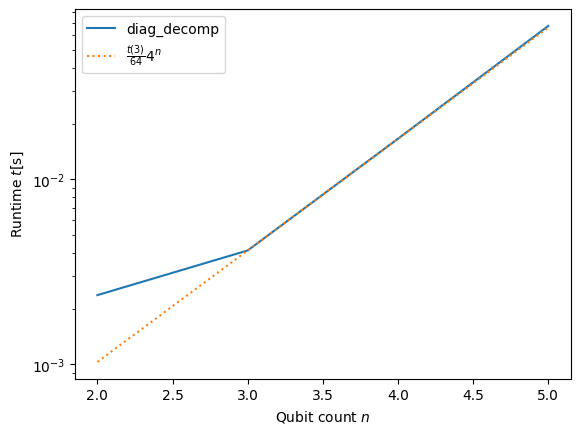

In [8]:
fig, ax = plt.subplots(1, 1)
ax.plot(ns, times, label="diag_decomp")
ax.plot(ns, 4**np.array(ns)*times[1]/4**ns[1], label="$\\frac{t(3)}{64} 4^n$", ls=":")
ax.set_yscale('log')
ax.legend()
ax.set_xlabel("Qubit count $n$")
ax.set_ylabel("Runtime $t$[s]")

In [9]:
# CNOT counts
gate_set = {"RZ", "RX", "RY", "S", "Hadamard", "GlobalPhase", "CNOT"}
dev =qml.device("default.qubit")

@qml.specs
# @partial(qml.transforms.decompose, gate_set=gate_set)
@partial(qml.clifford_t_decomposition, method="gridsynth", epsilon=1e-3)
@qml.qnode(dev)
def vanilla_qsd(u, wires):
    qml.QubitUnitary(u, wires=wires)
    return qml.expval(qml.Z(0))

@qml.specs
# @qml.draw
# @partial(qml.transforms.decompose, gate_set=gate_set)
@partial(qml.clifford_t_decomposition, method="gridsynth", epsilon=1e-3)
@qml.qnode(dev)
def new_qsd(u, wires):
    diag_decomp(u, wires=wires)
    return qml.expval(qml.Z(0))

In [14]:
n = 3
wires = list(range(n))
N = 2**n 
u = sp.stats.unitary_group.rvs(N)

vanilla_specs = vanilla_qsd(u, wires)

number_ops=66
epsilon=1.5151515151515151e-05


KeyboardInterrupt: 

In [11]:
new_specs = new_qsd(u, wires)

number_ops=27
epsilon=3.7037037037037037e-05
number_ops=27
epsilon=3.7037037037037037e-05


In [12]:
print(vanilla_specs["resources"].gate_types)
print(new_specs["resources"].gate_types)

defaultdict(<class 'int'>, {'Identity': 1, 'Adjoint(T)': 248, 'Hadamard': 742, 'Adjoint(S)': 131, 'T': 488, 'S': 236, 'PauliZ': 8, 'PauliX': 2, 'CNOT': 3, 'GlobalPhase': 1})
defaultdict(<class 'int'>, {'PauliY': 8, 'Adjoint(T)': 526, 'Hadamard': 1472, 'Adjoint(S)': 261, 'CNOT': 7, 'T': 940, 'S': 483, 'PauliZ': 5, 'PauliX': 1, 'Identity': 1, 'GlobalPhase': 1})


In [13]:
qml.SelectPauliRot([0.5, 0.2], control_wires=[0], target_wire=[1]).hyperparameters

{'control_wires': Wires([0]), 'target_wire': Wires([1]), 'rot_axis': 'Z'}